In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pynq import Overlay, allocate
import time

In [2]:
# Software convolution for verification
def conv2d_sw(image, kernel, norm_shift):
    H, W = image.shape
    K = kernel.shape[0]

    out_h = H - K + 1
    out_w = W - K + 1

    out = np.zeros((out_h, out_w), dtype=np.uint8)

    for i in range(out_h):
        for j in range(out_w):
            window = image[i:i+K, j:j+K]
            s = int(np.sum(window * kernel))

            # match HLS
            bias = (1 << (norm_shift - 1)) if norm_shift > 0 else 0
            result = (s + bias) >> norm_shift

            # CLAMP
            result = max(0, min(255, result))

            out[i, j] = result
    
    return out

In [3]:
# Initialize overlay and IPs
overlay = Overlay("../vivado/fpga_2d_convolution.bit")
dma = overlay.axi_dma
hls_ip = overlay.conv_dataflow_stream

In [4]:
# Helper functions to pack/unpack 8-bit pixels into 32-bit words for DMA transfer
def pack_pixels(image):
    flat = image.flatten()
    packed = np.zeros(( (len(flat)+3)//4, ), dtype=np.uint32)

    word = 0
    count = 0
    idx = 0

    for px in flat:
        word |= int(px) << (8 * count)
        count += 1
        
        if count == 4:
            packed[idx] = word
            idx += 1
            word = 0
            count = 0

    if count != 0:
        packed[idx] = word

    return packed

def unpack_pixels(packed, total_pixels):
    out = np.zeros(total_pixels, dtype=np.uint8)
    idx = 0

    finished = False
    for word in packed:
        for i in range(4):
            if idx < total_pixels:
                out[idx] = (word >> (8 * i)) & 0xFF
                idx += 1
            
            if idx >= total_pixels:
                finished = True
                break
            
        if finished:
            break

    return out

In [5]:
def conv2d_hw(image, kernel, norm_shift):
    flat_kernel = kernel.flatten()

    # 1. Write kernel
    for i in range(len(flat_kernel)):
        hls_ip.write(0x10 + 0x8*i, int(flat_kernel[i]))

    # 2. Write params
    H, W = image.shape
    hls_ip.write(0x58, H)
    hls_ip.write(0x60, W)
    hls_ip.write(0x68, norm_shift)

    # ===== TIMING START =====
    t0 = time.time()

    # 3. Pack input
    t_pack_start = time.time()
    packed_input = pack_pixels(image)

    input_buffer = allocate(shape=packed_input.shape, dtype=np.uint32)
    input_buffer[:] = packed_input
    t_pack_end = time.time()

    # 4. Allocate output buffer
    out_h = H - 2
    out_w = W - 2
    total_pixels = out_h * out_w
    packed_out_size = (total_pixels + 3) // 4

    output_buffer = allocate(shape=(packed_out_size,), dtype=np.uint32)

    try:
        # 5. Start IP
        hls_ip.write(0x00, 1)

        # 6. DMA + compute
        t_hw_start = time.time()

        dma.sendchannel.transfer(input_buffer) 
        dma.recvchannel.transfer(output_buffer)

        dma.sendchannel.wait()
        dma.recvchannel.wait()

        t_hw_end = time.time()

        # 7. Unpack output
        t_unpack_start = time.time()
        output = unpack_pixels(output_buffer, total_pixels)
        t_unpack_end = time.time()

        t1 = time.time()

    finally:
        input_buffer.freebuffer()
        output_buffer.freebuffer()

    return {
        "output": output.reshape(out_h, out_w),
        "total_time": t1 - t0,
        "hw_time": t_hw_end - t_hw_start,
        "pack_time": t_pack_end - t_pack_start,
        "unpack_time": t_unpack_end - t_unpack_start
    }

In [ ]:
# Kernels

# Sobel X, Sobel Y, and Gaussian kernels
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.int32)

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.int32)

gaussian = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.int32)

In [7]:
# Benchmarking
sizes = [2**i for i in range(2, 10)]  # 4 -> 512

rows = [] # Store results for DataFrame

def benchmark(kernel, norm_shift, label):
    sw_times = []
    hw_times = []

    for size in sizes:
        image = np.random.randint(0, 256, (size, size), dtype=np.uint8)

        # --- Software ---
        t0 = time.time()
        out_sw = conv2d_sw(image, kernel, norm_shift)
        t1 = time.time()

        # --- Hardware ---
        result = conv2d_hw(image, kernel, norm_shift)
        out_hw = result["output"]

        # correctness check
        assert np.array_equal(out_sw, out_hw), f"Mismatch at size {size}"

        rows.append({
            "kernel": label,
            "size": size,
            "sw_time": t1 - t0,
            "hw_total_time": result["total_time"],
            "hw_time": result["hw_time"],
            "pack_time": result["pack_time"],
            "unpack_time": result["unpack_time"]
        })

        sw_times.append(t1 - t0)
        hw_times.append(result["total_time"])

        print(f"{label} | {size}x{size} -> OK")

    return sw_times, hw_times

In [8]:
# Run all Kernels
results = {}

results["Sobel X"] = benchmark(sobel_x, norm_shift=0, label="Sobel X")
results["Sobel Y"] = benchmark(sobel_y, norm_shift=0, label="Sobel Y")
results["Gaussian"] = benchmark(gaussian, norm_shift=4, label="Gaussian")

Sobel X | 4x4 -> OK
Sobel X | 8x8 -> OK
Sobel X | 16x16 -> OK
Sobel X | 32x32 -> OK
Sobel X | 64x64 -> OK
Sobel X | 128x128 -> OK
Sobel X | 256x256 -> OK
Sobel X | 512x512 -> OK
Sobel Y | 4x4 -> OK
Sobel Y | 8x8 -> OK
Sobel Y | 16x16 -> OK
Sobel Y | 32x32 -> OK
Sobel Y | 64x64 -> OK
Sobel Y | 128x128 -> OK
Sobel Y | 256x256 -> OK
Sobel Y | 512x512 -> OK
Gaussian | 4x4 -> OK
Gaussian | 8x8 -> OK
Gaussian | 16x16 -> OK
Gaussian | 32x32 -> OK
Gaussian | 64x64 -> OK
Gaussian | 128x128 -> OK
Gaussian | 256x256 -> OK
Gaussian | 512x512 -> OK


In [9]:
from IPython.display import display

df = pd.DataFrame(rows)
df["speedup"] = df["sw_time"] / df["hw_total_time"]
df["overhead"] = df["pack_time"] + df["unpack_time"]
df["overhead_ratio"] = df["overhead"] / df["hw_total_time"]

print("=== Rows where HW is faster (speedup > 1) ===")
display(df[df["speedup"] > 1])

print("\n=== Average overhead ratio per kernel ===")
display(df.groupby("kernel")[["overhead_ratio"]].mean())

print("\n=== Full Results ===")
display(df)

=== Rows where HW is faster (speedup > 1) ===


,kernel,size,sw_time,hw_total_time,hw_time,pack_time,unpack_time,speedup,overhead,overhead_ratio
2,Sobel X,16,0.014247,0.007605,0.000412,0.001522,0.005264,1.873409,0.006786,0.892282
3,Sobel X,32,0.064841,0.026585,0.000418,0.003394,0.022360,2.439034,0.025753,0.968737
4,Sobel X,64,0.277427,0.107789,0.000428,0.011487,0.095459,2.573793,0.106946,0.992179
5,Sobel X,128,1.134117,0.439133,0.000554,0.043176,0.394983,2.582627,0.438159,0.997782
6,Sobel X,256,4.609515,1.770644,0.001058,0.169589,1.599550,2.603298,1.769139,0.999150
7,Sobel X,512,18.640985,7.129630,0.003042,0.676921,6.449043,2.614579,7.125965,0.999486
9,Sobel Y,8,0.002670,0.002556,0.000391,0.000785,0.001002,1.044395,0.001787,0.698937
10,Sobel Y,16,0.014130,0.006981,0.000398,0.001283,0.004915,2.023974,0.006198,0.887781
11,Sobel Y,32,0.064370,0.026491,0.000425,0.003249,0.022427,2.429873,0.025676,0.969220
12,Sobel Y,64,0.277114,0.109115,0.000431,0.011664,0.096588,2.539663,0.108252,0.992090



=== Average overhead ratio per kernel ===


,overhead_ratio
kernel,
Gaussian,0.900510
Sobel X,0.906861
Sobel Y,0.900655



=== Full Results ===


,kernel,size,sw_time,hw_total_time,hw_time,pack_time,unpack_time,speedup,overhead,overhead_ratio
0,Sobel X,4,0.000450,0.006157,0.001119,0.004191,0.000234,0.073105,0.004426,0.718733
1,Sobel X,8,0.002884,0.004551,0.000482,0.002072,0.001053,0.633630,0.003125,0.686537
2,Sobel X,16,0.014247,0.007605,0.000412,0.001522,0.005264,1.873409,0.006786,0.892282
3,Sobel X,32,0.064841,0.026585,0.000418,0.003394,0.022360,2.439034,0.025753,0.968737
4,Sobel X,64,0.277427,0.107789,0.000428,0.011487,0.095459,2.573793,0.106946,0.992179
5,Sobel X,128,1.134117,0.439133,0.000554,0.043176,0.394983,2.582627,0.438159,0.997782
6,Sobel X,256,4.609515,1.770644,0.001058,0.169589,1.599550,2.603298,1.769139,0.999150
7,Sobel X,512,18.640985,7.129630,0.003042,0.676921,6.449043,2.614579,7.125965,0.999486
8,Sobel Y,4,0.000369,0.002734,0.000423,0.001644,0.000163,0.134984,0.001807,0.660795
9,Sobel Y,8,0.002670,0.002556,0.000391,0.000785,0.001002,1.044395,0.001787,0.698937


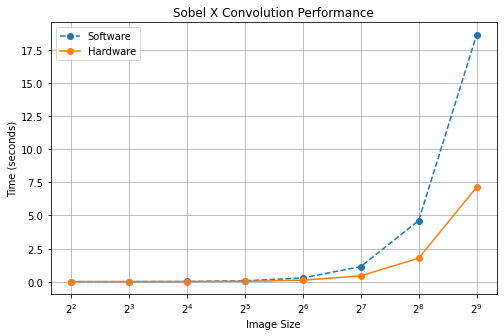

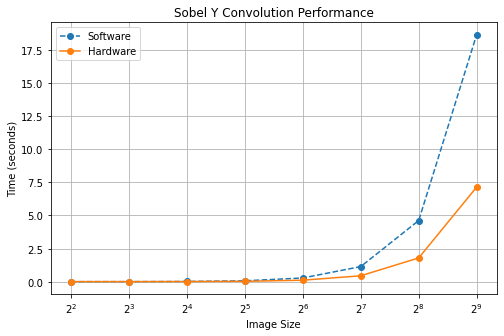

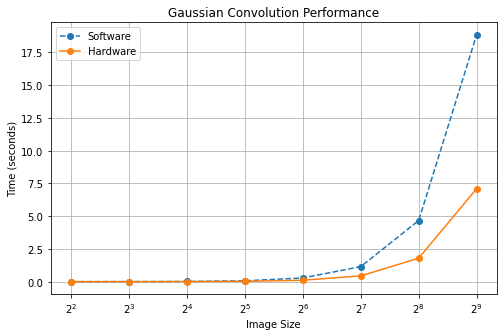

In [10]:
# Plot Software vs Hardware times against image size per kernel
for name, (sw_times, hw_times) in results.items():
    plt.figure(figsize=(8,5))

    plt.plot(sizes, sw_times, '--o', label="Software")
    plt.plot(sizes, hw_times, '-o', label="Hardware")

    plt.xlabel("Image Size")
    plt.ylabel("Time (seconds)")
    plt.title(f"{name} Convolution Performance")

    plt.xscale("log", base=2)
    plt.grid()
    plt.legend()

    plt.show()

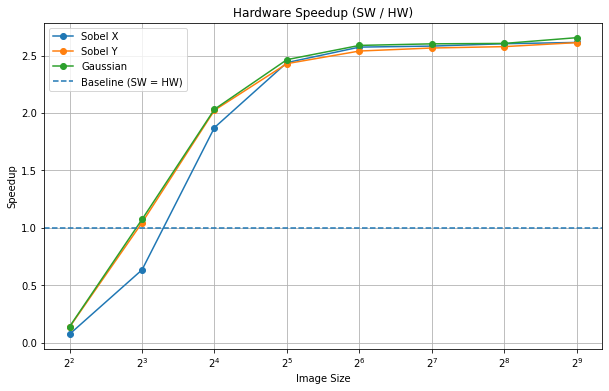

In [11]:
# Plot speedup (SW time / HW time) against image size per kernel
plt.figure(figsize=(10,6))
for kernel in df["kernel"].unique():
    subset = df[df["kernel"] == kernel].sort_values("size")
    plt.plot(subset["size"], subset["speedup"], '-o', label=kernel)

plt.axhline(1, linestyle='--', label="Baseline (SW = HW)")
plt.xscale("log", base=2)
plt.xlabel("Image Size")
plt.ylabel("Speedup")
plt.title("Hardware Speedup (SW / HW)")
plt.legend()
plt.grid()

plt.show()

The hardware implementation includes data packing/unpacking and DMA transfers, which introduce non-trivial overhead. 
For smaller input sizes, this overhead dominates execution time, resulting in lower overall performance compared to the software baseline. 
As input size increases, the impact of this overhead diminishes, and the streaming architecture becomes more efficient. 
Due to its pipelined design (II = 1), the hardware achieves near-constant throughput, leading to improved performance and observable speedup at larger scales.